In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from adjustText import adjust_text
from matplotlib.lines import Line2D
from scipy import stats

%load_ext autoreload
%autoreload 2

sys.path.insert(0, "..")
from plasmidtools import examplots, helpers


Paths

In [2]:
DATA_DIR = Path("../data")
FIG_DIR = DATA_DIR / "figures"
ADDGENE_DIR = DATA_DIR / "addgene"
ALIGN_DIR = DATA_DIR / "addgene_alignments"
MANUAL_DIR = DATA_DIR / "manual_annotations"
PLASMID_FASTA = ADDGENE_DIR / "mammalian_plasmids_wrapped.fasta"
GBK_DIR = DATA_DIR / "genbank"


Pre-processed / pre-calculated data

In [3]:
plasmid_citations = (
    pl.read_csv(ADDGENE_DIR / "mammalian_plasmids.tsv", separator="\t")
    .join(pl.read_parquet(ADDGENE_DIR / "citations_addgene.parquet"), on="plasmid_id")
)

plasmid_stats = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_statistics.parquet")
    .join(plasmid_citations, on="sequence_id")
)

element_positions = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_elements.parquet")
element_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene_elements.parquet")
cre_annotation = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_cre_and_tss.parquet")


CRE annotation across Addgene elements

In [4]:
ccc_clustered = pl.read_csv(ADDGENE_DIR / "element_cre_overlap_clustering.csv")
ccc_heatmap = pl.read_csv(ADDGENE_DIR / "element_cre_overlap_clustering_heatmap.csv")


The CDSs (Transgenes) are manually assigned a `function` and further annotated as `recurrent_payload` based on the following operational definition:

A **recurrent payload CDS** is a protein-coding sequence (CDS) with all of the following properties:
1. Encodes a protein with a defined molecular role (e.g., fluorescence, enzymatic activity, site-specific recombination).
2. Backbone-context independence — Function is preserved across diverse vector architectures (different promoters, selection cassettes, backbone origins, delivery modalities).
3. Discrete boundaries — Defined by start and stop codons, extractable as a self-contained unit distinct from surrounding vector elements.
4. Widely distributed — Present in ≥ N distinct plasmids spanning diverse backbone contexts; aggregate usage is substantial even if individual plasmids are not highly cited.
5. Minimum length ≥ X bp — Long enough (≥ L bp) to plausibly harbor functional CRE elements.
6. Sequence-clustered — Instances across plasmids are assigned to the same CDS type if they share ≥ Y% pairwise nucleotide identity over ≥ Z% of alignment length, capturing codon-optimized variants, minor mutations, and short appended tags as a single entry.

Filtering is performed in the [`13_payload_cds_cres.py`](../scripts/13_payload_cds_cres.py) script.

In [5]:
CRE_LENGTH_THRESH = 100  # the same as in the ../scripts/10_element_cccs.py

cds_payloads = (
    pl.read_csv(MANUAL_DIR / "addgene_cds_payloads.csv")
    .filter(pl.col("length") >= CRE_LENGTH_THRESH)
)


### 1. CRE frequency in Payload CDSs

Research questions:

- What number of CDS types (stratified by being recurrent paylods) possess a cryptic CRE? How popular (\# plasmids, \# citations) are these CDSs?

- How is CRE activity (each of the five CRE metrics) distributed across CDSs. What is the case specifically for recurrently used payload CDSs?

- Control: Do CRE metrics depend on CDS length?

- Supplement: is a certain function associated with a CDS having a CRE?


In [6]:
df = cds_payloads.join(
    ccc_clustered.select('type', 'name', 'n_cre_midpoints', 'cre_avg_signal', 'fraction_cre_bp', 'n_tss_midpoints', 'tss_avg_signal', 'n_active_metrics', 'composite_z_score', 'priority_group', 'is_cryptic_cre'),
    left_on=["element_type", "element_name"], right_on=["type", "name"],
    how="left"
)


What number of CDS types (stratified by being recurrent paylods) possess a cryptic CRE?


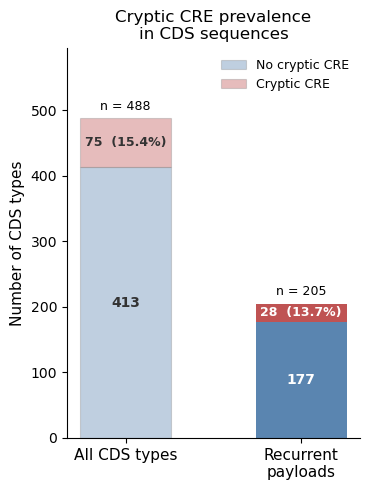

In [7]:
def plot_cds_cre_counts(df: pl.DataFrame) -> plt.Figure:
    """
    Panel A: Stacked bar chart — cryptic CRE prevalence in CDS types.

    Bar 1 (reference, de-emphasised): all 488 CDS types — establishes the
        overall baseline frequency of cryptic CREs.
    Bar 2 (focal, full colour):       recurrent payload CDSs — the
        scientifically most relevant sub-group.
    """
    # ── aggregate ─────────────────────────────────────────────────────────────
    def _n(recurrent_filter, cryptic):
        q = df if recurrent_filter is None else df.filter(
            pl.col("is_recurrent_payload") == recurrent_filter
        )
        return q.filter(pl.col("is_cryptic_cre") == cryptic).height

    not_cryptic = np.array([_n(None, False), _n(True, False)])
    cryptic     = np.array([_n(None, True),  _n(True, True)])
    totals      = not_cryptic + cryptic
    pcts        = cryptic / totals * 100
    xlabels     = ["All CDS types", "Recurrent\npayloads"]

    color_base    = "#4878a8"   # steel blue
    color_cryptic = "#b84040"   # crimson

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(3.8, 5))

    x         = np.array([0.0, 0.85])   # close spacing implies subset relationship
    bar_width = 0.44

    # bar 0 — reference: same hue, low alpha, grey outline
    ax.bar(x[0], not_cryptic[0], width=bar_width,
           color=color_base, alpha=0.35,
           edgecolor="#888888", linewidth=0.8,
           label="No cryptic CRE")
    ax.bar(x[0], cryptic[0], width=bar_width, bottom=not_cryptic[0],
           color=color_cryptic, alpha=0.35,
           edgecolor="#888888", linewidth=0.8,
           label="Cryptic CRE")

    # bar 1 — focal: full saturation, no outline
    ax.bar(x[1], not_cryptic[1], width=bar_width,
           color=color_base, alpha=0.90, linewidth=0)
    ax.bar(x[1], cryptic[1], width=bar_width, bottom=not_cryptic[1],
           color=color_cryptic, alpha=0.90, linewidth=0)

    # ── segment labels ────────────────────────────────────────────────────────
    for i, (nc, c, pct, tot) in enumerate(zip(not_cryptic, cryptic, pcts, totals)):
        is_focal  = (i == 1)
        inner_col = "white" if is_focal else "#333333"

        # count inside base segment
        ax.text(x[i], nc / 2, str(nc),
                ha="center", va="center", fontsize=10,
                color=inner_col, fontweight="bold")

        # count + % inside (or above) cryptic segment
        label = f"{c}  ({pct:.1f}%)"
        if c >= 20:
            ax.text(x[i], nc + c / 2, label,
                    ha="center", va="center", fontsize=9,
                    color=inner_col, fontweight="bold")
            n_offset = 8
        else:
            ax.text(x[i], tot + 6, label,
                    ha="center", va="bottom", fontsize=9,
                    color=color_cryptic if is_focal else "#888888")
            n_offset = 22

        # total n above bar
        ax.text(x[i], tot + n_offset, f"n = {tot}",
                ha="center", va="bottom", fontsize=9, color="black")

    # ── axes chrome ───────────────────────────────────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=11)
    ax.set_ylabel("Number of CDS types", fontsize=11)
    ax.set_ylim(0, max(totals) * 1.22)
    ax.set_title("Cryptic CRE prevalence\nin CDS sequences", fontsize=12)
    ax.legend(frameon=False, fontsize=9, loc="upper right")

    sns.despine()
    plt.tight_layout()
    return fig


fig = plot_cds_cre_counts(df)
plt.show()

How popular (\# plasmids, \# citations) are CDSs with cryptic CREs?

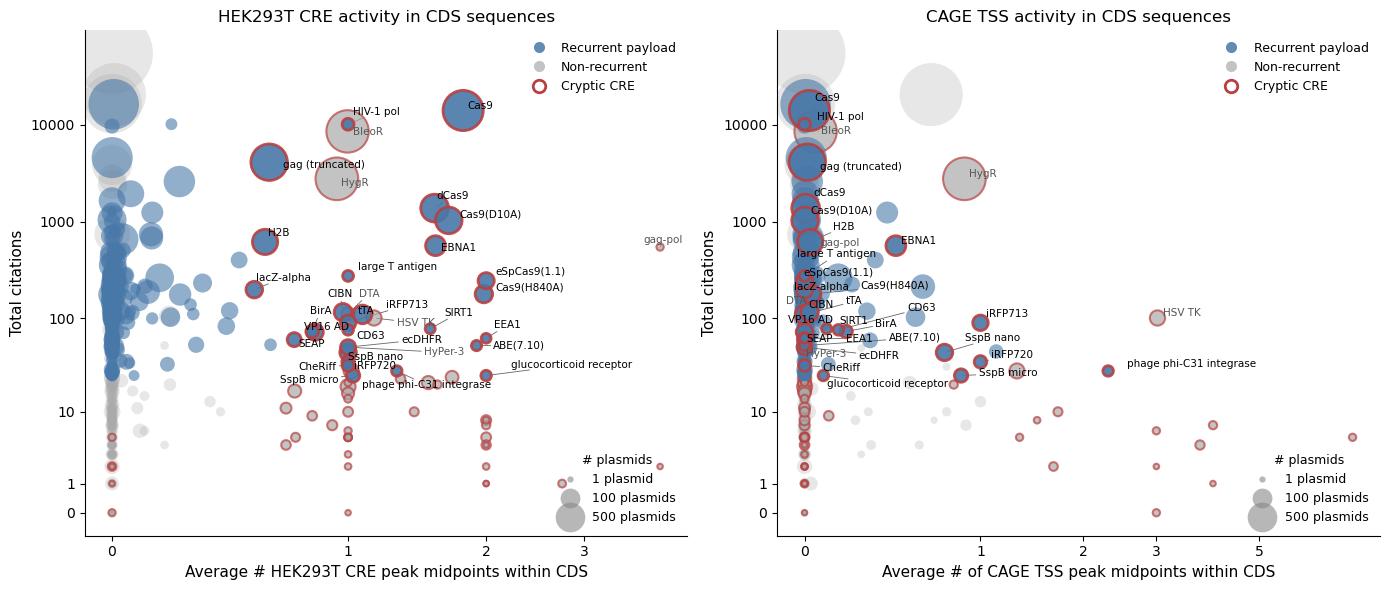

In [8]:
def plot_cre_bubble(
    df: pl.DataFrame,
    x_col: str,
    ax: plt.Axes | None = None,
    x_label: str | None = None,
    title: str | None = None,
) -> plt.Axes:
    """
    Panels B1 / B2 — bubble scatter.

    x    : x_col (CRE or TSS peak count per CDS), log1p-scaled
    y    : n_citations, log1p-scaled
    size : n_plasmids  (bubble area ∝ √n_plasmids)
    color: recurrent payloads (blue) vs. non-recurrent (grey)
    edge : crimson = cryptic CRE (both groups)
    label: element_name for recurrent + cryptic CDSs only
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))

    x_label = x_label or x_col
    title   = title   or x_col

    C_REC    = "#4878a8"   # steel blue
    C_NONREC = "#aaaaaa"   # neutral grey
    C_EDGE   = "#b84040"   # crimson
    S_SCALE  = 16          # bubble area = sqrt(n_plasmids) * S_SCALE

    def _arr(sub: pl.DataFrame):
        xv = np.log1p(sub[x_col].cast(pl.Float64).to_numpy())
        yv = np.log1p(sub["n_citations"].cast(pl.Float64).to_numpy())
        sv = np.sqrt(sub["n_plasmids"].cast(pl.Float64).to_numpy()) * S_SCALE
        nm = sub["element_name"].to_list()
        return xv, yv, sv, nm

    is_rec = pl.col("is_recurrent_payload")
    is_cre = pl.col("is_cryptic_cre")

    # sort descending so large bubbles land in the background
    srt = {"by": "n_plasmids", "descending": True}
    nr_base  = df.filter(~is_rec & ~is_cre).sort(**srt)
    nr_cre   = df.filter(~is_rec &  is_cre).sort(**srt)
    rec_base = df.filter( is_rec & ~is_cre).sort(**srt)
    rec_cre  = df.filter( is_rec &  is_cre).sort(**srt)

    # ── scatter layers (back → front) ─────────────────────────────────────────
    x, y, s, _     = _arr(nr_base)
    ax.scatter(x, y, s=s, c=C_NONREC, alpha=0.28, linewidths=0, zorder=1)

    x, y, s, _     = _arr(nr_cre)
    ax.scatter(x, y, s=s, c=C_NONREC, alpha=0.70,
               edgecolors=C_EDGE, linewidths=1.5, zorder=2)

    x, y, s, _     = _arr(rec_base)
    ax.scatter(x, y, s=s, c=C_REC, alpha=0.60, linewidths=0, zorder=3)

    x, y, s, names = _arr(rec_cre)
    ax.scatter(x, y, s=s, c=C_REC, alpha=0.90,
               edgecolors=C_EDGE, linewidths=2.0, zorder=4)

    # ── labels: recurrent + cryptic only ──────────────────────────────────────
    texts = [
        ax.text(x[i], y[i], names[i], fontsize=7.5, color="black", zorder=5)
        for i in range(len(x))
    ]

    nr_cre_cited = df.filter(
        ~is_rec & is_cre & (pl.col("n_citations") >= 50)
    ).sort(**srt)
    if nr_cre_cited.height > 0:
        x_nr, y_nr, _, names_nr = _arr(nr_cre_cited)
        texts += [
            ax.text(x_nr[i], y_nr[i], names_nr[i],
                    fontsize=7.5, color="#555555", zorder=5)  # slightly muted vs. recurrent
            for i in range(len(x_nr))
        ]

    if texts:
        adjust_text(texts, ax=ax,
                    arrowprops={"arrowstyle": "-", "color": "#666666", "lw": 0.6})

    # ── axes ──────────────────────────────────────────────────────────────────
    raw_x  = df[x_col].cast(pl.Float64).to_numpy()
    xticks = [v for v in [0, 1, 2, 3, 5, 10, 20, 30] if v <= raw_x.max()]
    ax.set_xticks(np.log1p(xticks))
    ax.set_xticklabels(xticks)
    ax.set_xlabel(x_label, fontsize=11)

    raw_y  = df["n_citations"].cast(pl.Float64).to_numpy()
    yticks = [v for v in [0, 1, 10, 100, 1000, 10000, 100000] if v <= raw_y.max()]
    ax.set_yticks(np.log1p(yticks))
    ax.set_yticklabels(yticks)
    ax.set_ylabel("Total citations", fontsize=11)

    ax.set_title(title, fontsize=12)

    # ── colour / type legend ──────────────────────────────────────────────────
    type_handles = [
        Line2D([0], [0], marker='o', linestyle='none', markersize=8,
               markerfacecolor=C_REC, markeredgewidth=0,
               alpha=0.85, label="Recurrent payload"),
        Line2D([0], [0], marker='o', linestyle='none', markersize=8,
               markerfacecolor=C_NONREC, markeredgewidth=0,
               alpha=0.70, label="Non-recurrent"),
        Line2D([0], [0], marker='o', linestyle='none', markersize=9,
               markerfacecolor='white', markeredgecolor=C_EDGE,
               markeredgewidth=2.0, label="Cryptic CRE"),
    ]
    leg1 = ax.legend(handles=type_handles, frameon=False,
                     fontsize=9, loc="upper right")
    ax.add_artist(leg1)   # preserve while second legend is added

    # ── size legend ───────────────────────────────────────────────────────────
    n_max     = int(df["n_plasmids"].max())
    size_vals = [v for v in [1, 10, 100, 500] if v <= n_max]
    if len(size_vals) > 3:
        size_vals = [size_vals[0], size_vals[len(size_vals) // 2], size_vals[-1]]

    def _ms(n):
        """n_plasmids → Line2D markersize that visually matches scatter area."""
        return 2 * np.sqrt(np.sqrt(n) * S_SCALE / np.pi)

    size_handles = [
        Line2D([0], [0], marker='o', linestyle='none',
               markerfacecolor="#888888", markeredgewidth=0,
               alpha=0.60, markersize=_ms(v),
               label=f"{v} plasmid{'s' if v > 1 else ''}")
        for v in size_vals
    ]
    ax.legend(handles=size_handles, frameon=False, fontsize=9,
              loc="lower right", title="# plasmids", title_fontsize=9)

    sns.despine()
    return ax


# # ── individual figures ────────────────────────────────────────────────────────
# fig_b1, ax_b1 = plt.subplots(figsize=(7, 6))
# plot_cre_bubble(df, "n_cre_midpoints", ax=ax_b1, x_label="Average # HEK293T CRE peak midpoints within CDS", title="HEK293T CRE activity in CDS sequences")
# plt.tight_layout()

# fig_b2, ax_b2 = plt.subplots(figsize=(7, 6))
# plot_cre_bubble(df, "n_tss_midpoints", ax=ax_b2, x_label="Average # of CAGE TSS peak midpoints within CDS", title="CAGE TSS activity in CDS sequences")
# plt.tight_layout()
# plt.show()

# # ── combined ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_cre_bubble(df, "n_cre_midpoints", ax=axes[0], x_label="Average # HEK293T CRE peak midpoints within CDS", title="HEK293T CRE activity in CDS sequences")
plot_cre_bubble(df, "n_tss_midpoints", ax=axes[1], x_label="Average # of CAGE TSS peak midpoints within CDS", title="CAGE TSS activity in CDS sequences")
plt.tight_layout()


How is CRE activity (each of the five CRE metrics) distributed across CDSs. What is the case specifically for recurrently used payload CDSs?

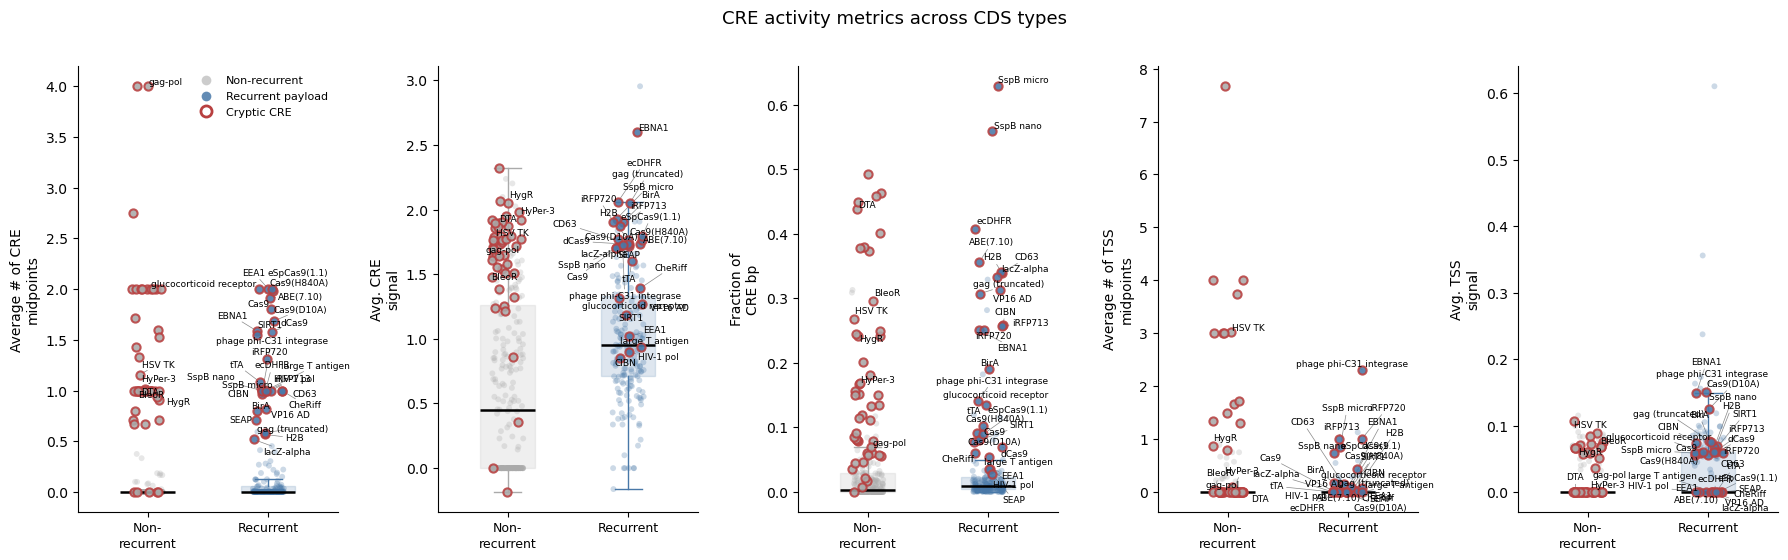

In [9]:
METRICS = [
    ("n_cre_midpoints", "Average # of CRE\nmidpoints"),
    ("cre_avg_signal",  "Avg. CRE\nsignal"),
    ("fraction_cre_bp", "Fraction of\nCRE bp"),
    ("n_tss_midpoints", "Average # of TSS\nmidpoints"),
    ("tss_avg_signal",  "Avg. TSS\nsignal"),
]


def plot_cre_metrics_distribution(df: pl.DataFrame) -> plt.Figure:
    """
    Panel C: Distribution of the five CRE activity metrics.

    Each subplot: box + strip for two groups (non-recurrent / recurrent).
    Cryptic CRE dots carry a crimson outline.
    Text labels:
      - all recurrent + cryptic CDSs
      - non-recurrent + cryptic CDSs with n_citations >= 50
    """
    rng = np.random.default_rng(42)

    C_REC     = "#4878a8"
    C_NONREC  = "#aaaaaa"
    C_CRYPTIC = "#b84040"

    is_rec = pl.col("is_recurrent_payload")
    is_cre = pl.col("is_cryptic_cre")

    fig, axes = plt.subplots(1, 5, figsize=(18, 5.5))

    for ax, (col, ylabel) in zip(axes, METRICS):

        # ── boxplot per group ──────────────────────────────────────────────────
        for grp_x, grp_filter, grp_color in [
            (0, ~is_rec, C_NONREC),
            (1,  is_rec, C_REC),
        ]:
            vals = df.filter(grp_filter)[col].cast(pl.Float64).to_numpy()
            ax.boxplot(
                vals,
                positions     = [grp_x],
                widths        = 0.45,
                patch_artist  = True,
                showfliers    = False,
                medianprops   = {"color": "black",    "lw": 1.8},
                boxprops      = {"facecolor": grp_color, "alpha": 0.18,
                                 "edgecolor": grp_color, "linewidth": 1.0},
                whiskerprops  = {"color": grp_color,  "lw": 1.0},
                capprops      = {"color": grp_color,  "lw": 1.0},
            )

        # ── strip plots ────────────────────────────────────────────────────────
        label_xs, label_ys, label_names, label_is_rec = [], [], [], []  # ← added label_is_rec

        for grp_x, rec_val, color in [(0, False, C_NONREC), (1, True, C_REC)]:
            for cre_val in [False, True]:
                sub   = df.filter((is_rec == rec_val) & (is_cre == cre_val))
                vals  = sub[col].cast(pl.Float64).to_numpy()
                cites = sub["n_citations"].cast(pl.Float64).to_numpy()
                n     = len(vals)
                jit   = rng.uniform(-0.13, 0.13, n)
                xs    = np.full(n, grp_x, dtype=float) + jit

                ax.scatter(
                    xs, vals,
                    s          = 35  if cre_val else 18,
                    color      = color,
                    alpha      = 0.88 if cre_val else 0.28,
                    edgecolors = C_CRYPTIC if cre_val else "none",
                    linewidths = 1.5  if cre_val else 0,
                    zorder     = 4    if cre_val else 2,
                )

                # labels: all recurrent+cryptic; non-recurrent+cryptic if cited ≥ 50
                if cre_val:
                    cited_mask = (
                        np.ones(n, dtype=bool)   # all recurrent
                        if rec_val
                        else cites >= 50          # only high-cited non-recurrent
                    )
                    label_xs.extend(xs[cited_mask].tolist())
                    label_ys.extend(vals[cited_mask].tolist())
                    label_names.extend(
                        np.array(sub["element_name"].to_list())[cited_mask].tolist()
                    )
                    label_is_rec.extend([rec_val] * int(cited_mask.sum()))

        # ── text labels ────────────────────────────────────────────────────────
        texts = [
            ax.text(
                label_xs[i], label_ys[i], label_names[i],
                fontsize = 6.5, zorder = 5,
                color    = "black" # if label_is_rec[i] else "#555555",
            )
            for i in range(len(label_names))
        ]
        if texts:
            adjust_text(
                texts, ax=ax,
                arrowprops={"arrowstyle": "-", "color": "#888888", "lw": 0.5},
            )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Non-\nrecurrent", "Recurrent"], fontsize=9)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xlim(-0.58, 1.58)
        sns.despine(ax=ax)

    # ── shared legend ──────────────────────────────────────────────────────────
    leg_handles = [
        Line2D([0], [0], marker="o", linestyle="none", markersize=7,
               markerfacecolor=C_NONREC, markeredgewidth=0, alpha=0.6,
               label="Non-recurrent"),
        Line2D([0], [0], marker="o", linestyle="none", markersize=7,
               markerfacecolor=C_REC, markeredgewidth=0, alpha=0.85,
               label="Recurrent payload"),
        Line2D([0], [0], marker="o", linestyle="none", markersize=8,
               markerfacecolor="white", markeredgecolor=C_CRYPTIC,
               markeredgewidth=2.0, label="Cryptic CRE"),
    ]
    axes[0].legend(handles=leg_handles, frameon=False, fontsize=8,
                   loc="upper right")

    fig.suptitle("CRE activity metrics across CDS types", fontsize=13, y=1.01)
    plt.tight_layout()
    return fig


fig_c = plot_cre_metrics_distribution(df)
plt.show()


Control / supplement: Do CRE metrics depend on CDS length?

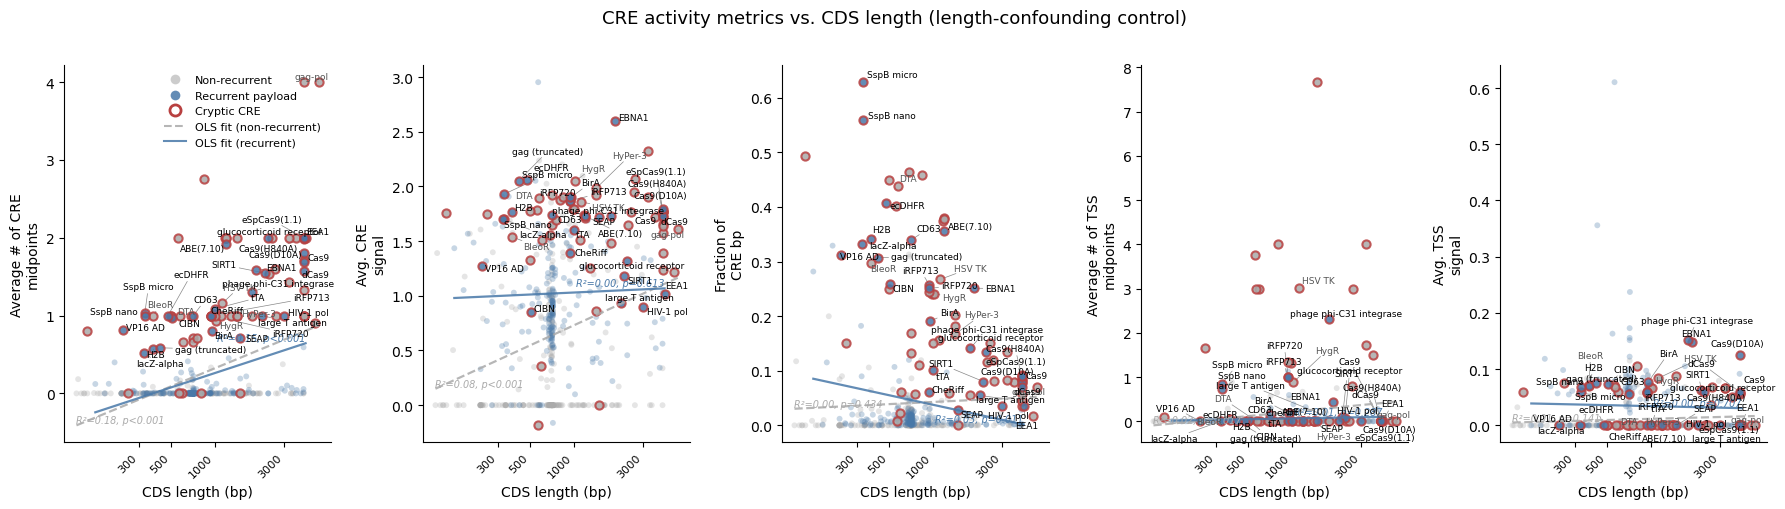

In [10]:
def plot_cre_length_control(df: pl.DataFrame) -> plt.Figure:
    """
    Supplementary RQ3 — CRE metric vs. CDS length (log-scaled x).

    Each of the five CRE metrics is plotted against median CDS length.
    An OLS regression line is fitted per group (recurrent / non-recurrent)
    on log1p(length); R² and p-value are annotated for each group.

    Cryptic CRE points carry a crimson outline (consistent with panels B/C).
    Recurrent + cryptic and high-cited (≥50) non-recurrent + cryptic CDSs
    are labeled (consistent with panels B/C).
    """
    _ = np.random.default_rng(42)

    C_REC     = "#4878a8"
    C_NONREC  = "#aaaaaa"
    C_CRYPTIC = "#b84040"

    is_rec = pl.col("is_recurrent_payload")
    is_cre = pl.col("is_cryptic_cre")

    length_log = np.log1p(df["length"].cast(pl.Float64).to_numpy())

    fig, axes = plt.subplots(1, 5, figsize=(18, 5.0))

    for ax, (col, ylabel) in zip(axes, METRICS):

        y_all = df[col].cast(pl.Float64).to_numpy()

        label_xs, label_ys, label_names, label_is_rec = [], [], [], []

        # ── scatter + labels per group × cryptic status ───────────────────────
        for rec_val, color in [(False, C_NONREC), (True, C_REC)]:
            for cre_val in [False, True]:
                mask = (
                    (df["is_recurrent_payload"] == rec_val) &
                    (df["is_cryptic_cre"]        == cre_val)
                ).to_numpy()

                xv    = length_log[mask]
                yv    = y_all[mask]
                cites = df.filter(
                    (is_rec == rec_val) & (is_cre == cre_val)
                )["n_citations"].cast(pl.Float64).to_numpy()

                ax.scatter(
                    xv, yv,
                    s          = 35  if cre_val else 18,
                    color      = color,
                    alpha      = 0.85 if cre_val else 0.30,
                    edgecolors = C_CRYPTIC if cre_val else "none",
                    linewidths = 1.5  if cre_val else 0,
                    zorder     = 4    if cre_val else 2,
                )

                if cre_val:
                    cited_mask = (
                        np.ones(len(xv), dtype=bool)
                        if rec_val
                        else cites >= 50
                    )
                    names = np.array(
                        df.filter(
                            (is_rec == rec_val) & (is_cre == cre_val)
                        )["element_name"].to_list()
                    )
                    label_xs.extend(xv[cited_mask].tolist())
                    label_ys.extend(yv[cited_mask].tolist())
                    label_names.extend(names[cited_mask].tolist())
                    label_is_rec.extend([rec_val] * int(cited_mask.sum()))

        # ── OLS trend lines ───────────────────────────────────────────────────
        _ = ax.get_ylim()[1]   # updated after scatter; re-queried below

        for grp_idx, (rec_val, color, ha) in enumerate([
            (False, C_NONREC, "left"),
            (True,  C_REC,    "right"),
        ]):
            mask = (df["is_recurrent_payload"] == rec_val).to_numpy()
            xv   = length_log[mask]
            yv   = y_all[mask]

            if len(xv) < 3:
                continue

            slope, intercept, r, p, _ = stats.linregress(xv, yv)
            x_line = np.linspace(xv.min(), xv.max(), 200)
            y_line = slope * x_line + intercept

            ax.plot(x_line, y_line,
                    color=color, lw=1.6, alpha=0.85,
                    linestyle="--" if not rec_val else "-",
                    zorder=5)

            # R² and p annotation — placed at the right/left edge of the line
            p_str   = "p<0.001" if p < 0.001 else f"p={p:.3f}"
            annot   = f"R²={r**2:.2f}, {p_str}"
            x_annot = x_line[-1] if ha == "right" else x_line[0]
            y_annot = y_line[-1] if ha == "right" else y_line[0]

            ax.text(
                x_annot, y_annot, annot,
                ha=ha, va="bottom",
                fontsize=7, color=color,
                fontstyle="italic", zorder=6,
            )

        # ── text labels ───────────────────────────────────────────────────────
        texts = [
            ax.text(
                label_xs[i], label_ys[i], label_names[i],
                fontsize = 6.5, zorder = 7,
                color    = "black" if label_is_rec[i] else "#555555",
            )
            for i in range(len(label_names))
        ]
        if texts:
            adjust_text(
                texts, ax=ax,
                arrowprops={"arrowstyle": "-", "color": "#888888", "lw": 0.5},
            )

        # ── axes chrome ───────────────────────────────────────────────────────
        raw_len = df["length"].cast(pl.Float64).to_numpy()
        xticks  = [v for v in [100, 300, 500, 1000, 3000, 6000, 10000]
                   if raw_len.min() <= v <= raw_len.max()]
        ax.set_xticks(np.log1p(xticks))
        ax.set_xticklabels(xticks, rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("CDS length (bp)", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        sns.despine(ax=ax)

    # ── shared legend on first panel ──────────────────────────────────────────
    leg_handles = [
        Line2D([0], [0], marker="o", linestyle="none", markersize=7,
               markerfacecolor=C_NONREC, markeredgewidth=0, alpha=0.6,
               label="Non-recurrent"),
        Line2D([0], [0], marker="o", linestyle="none", markersize=7,
               markerfacecolor=C_REC, markeredgewidth=0, alpha=0.85,
               label="Recurrent payload"),
        Line2D([0], [0], marker="o", linestyle="none", markersize=8,
               markerfacecolor="white", markeredgecolor=C_CRYPTIC,
               markeredgewidth=2.0, label="Cryptic CRE"),
        Line2D([0], [0], linestyle="--", color=C_NONREC, lw=1.5, alpha=0.85,
               label="OLS fit (non-recurrent)"),
        Line2D([0], [0], linestyle="-",  color=C_REC,    lw=1.5, alpha=0.85,
               label="OLS fit (recurrent)"),
    ]
    axes[0].legend(handles=leg_handles, frameon=False, fontsize=8,
                   loc="upper right")

    fig.suptitle(
        "CRE activity metrics vs. CDS length (length-confounding control)",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    return fig


fig_supp = plot_cre_length_control(df)
plt.show()

Control / supplement: is a certain function associated with a CDS having a CRE?

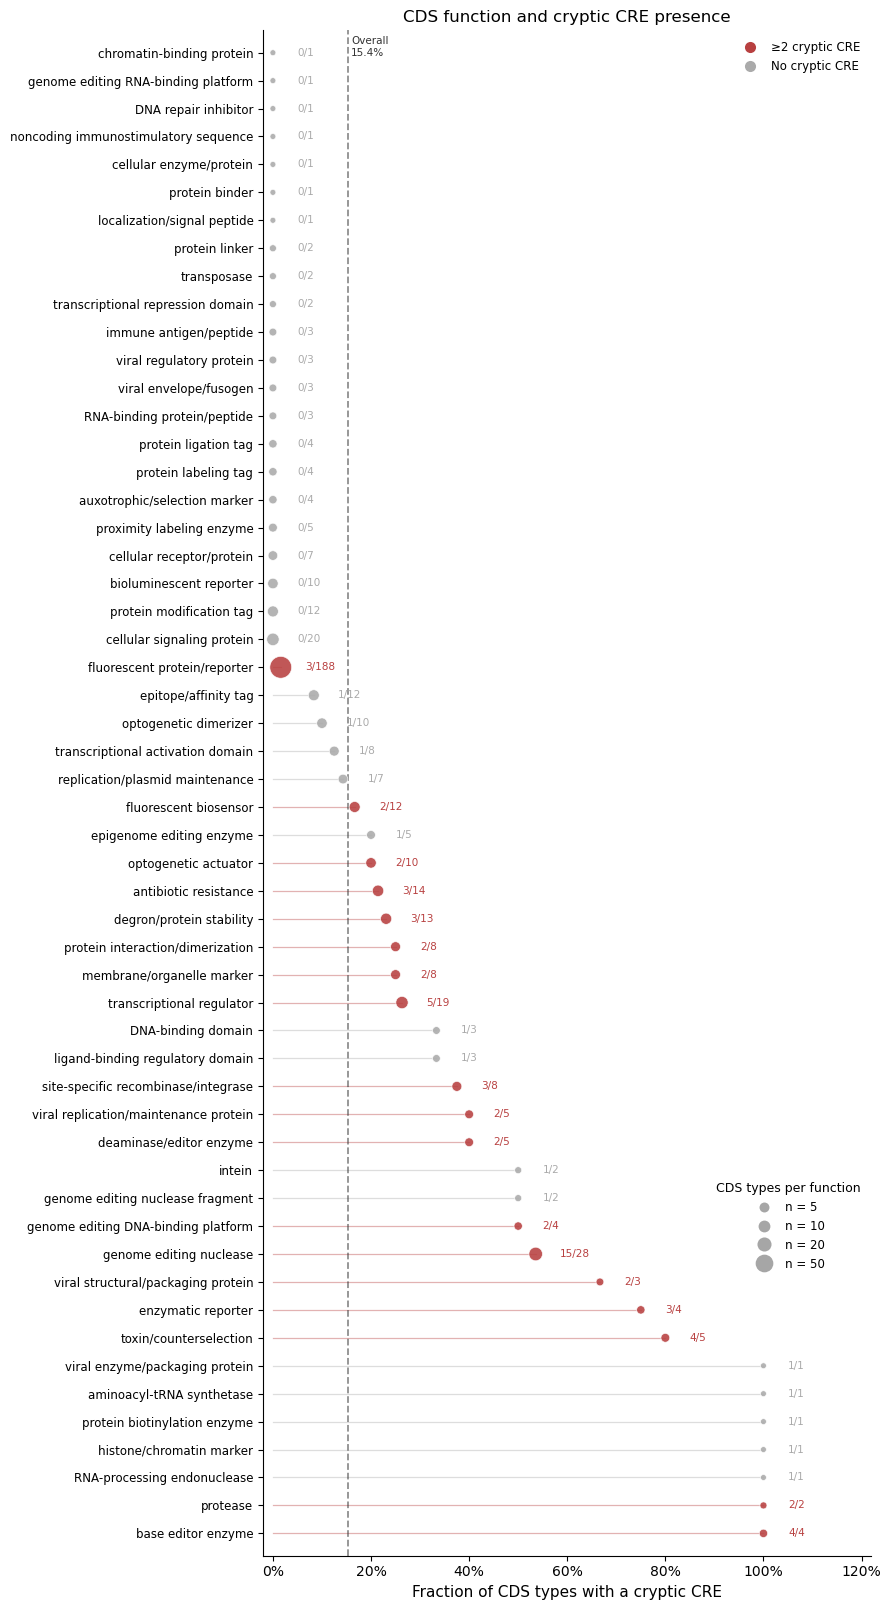

In [11]:
def plot_function_cre_association(df: pl.DataFrame) -> plt.Figure:
    """
    Supplementary — empirical association between CDS function and cryptic CRE.

    Horizontal lollipop chart:
      y    : CDS function, sorted by fraction cryptic (ties broken by n_total)
      x    : fraction of CDS types in that function with is_cryptic_cre == True
      size : total number of CDS types with that function
      color: any cryptic CREs present (crimson) vs. none (grey)
      text : "n_cryptic / n_total" annotated next to each dot
    """
    C_CRYPTIC = "#b84040"   # crimson — any cryptic CRE present
    C_NONE    = "#aaaaaa"   # grey    — no cryptic CRE in this function
    C_REF     = "#333333"   # overall rate reference line
    S_SCALE   = 18          # scatter area = sqrt(n_total) * S_SCALE

    # ── per-function aggregation ──────────────────────────────────────────────
    n_cryptic_all = int(df["is_cryptic_cre"].cast(pl.Int32).sum())
    overall_rate  = n_cryptic_all / df.height

    rows = []
    for func in df["function"].unique().to_list():
        sub       = df.filter(pl.col("function") == func)
        n_total   = sub.height
        n_cryptic = int(sub["is_cryptic_cre"].cast(pl.Int32).sum())
        rows.append({
            "function":  func,
            "n_total":   n_total,
            "n_cryptic": n_cryptic,
            "fraction":  n_cryptic / n_total,
        })

    stats_df = (
        pl.DataFrame(rows)
        .sort(["fraction", "n_total"], descending=[True, True])
    )

    funcs      = stats_df["function"].to_list()
    fractions  = stats_df["fraction"].to_numpy()
    n_totals   = stats_df["n_total"].to_numpy()
    n_cryptics = stats_df["n_cryptic"].to_numpy()
    colors     = np.where(n_cryptics > 1, C_CRYPTIC, C_NONE)

    y_pos   = np.arange(len(funcs))
    n_funcs = len(funcs)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, max(7, n_funcs * 0.30)))

    # lollipop stems
    for i, (frac, col) in enumerate(zip(fractions, colors)):
        ax.plot([0, frac], [i, i], color=col, lw=0.9, alpha=0.40, zorder=1)

    # dots sized by n_total
    ax.scatter(
        fractions, y_pos,
        s          = np.sqrt(n_totals) * S_SCALE,
        c          = colors,
        alpha      = 0.88,
        edgecolors = "white",
        linewidths = 0.5,
        zorder     = 3,
    )

    # "n_cryptic / n_total" annotation next to every dot
    for i, (frac, nc, nt, col) in enumerate(
        zip(fractions, n_cryptics, n_totals, colors)
    ):
        ax.text(
            frac + 0.05, i, f"{nc}/{nt}",
            va="center", ha="left", fontsize=7.5, color=col,
        )

    # overall rate reference line
    ax.axvline(overall_rate, color=C_REF, lw=1.3,
               linestyle="--", alpha=0.55, zorder=2)
    ax.text(
        overall_rate + 0.006, n_funcs - 0.4,
        f"Overall\n{overall_rate:.1%}",
        fontsize=7.5, color=C_REF, va="top",
    )

    # ── axes chrome ───────────────────────────────────────────────────────────
    ax.set_yticks(y_pos)
    ax.set_yticklabels(funcs, fontsize=8.5)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_xlabel("Fraction of CDS types with a cryptic CRE", fontsize=11)
    ax.set_xlim(-0.02, max(fractions.max() * 1.22, overall_rate * 2.8))
    ax.set_ylim(-0.8, n_funcs - 0.2)
    ax.set_title(
        "CDS function and cryptic CRE presence",
        fontsize=12,
    )

    # ── colour legend ─────────────────────────────────────────────────────────
    def _ms(n):
        return 2 * np.sqrt(np.sqrt(n) * S_SCALE / np.pi)

    color_handles = [
        Line2D([0], [0], marker="o", linestyle="none", markersize=8,
               markerfacecolor=C_CRYPTIC, markeredgewidth=0,
               label="≥2 cryptic CRE"),
        Line2D([0], [0], marker="o", linestyle="none", markersize=8,
               markerfacecolor=C_NONE, markeredgewidth=0,
               label="No cryptic CRE"),
    ]
    leg1 = ax.legend(handles=color_handles, frameon=False, fontsize=8.5,
                     loc="upper right")
    ax.add_artist(leg1)

    # ── size legend ───────────────────────────────────────────────────────────
    size_vals = [v for v in [1, 5, 10, 20, 50] if v <= int(n_totals.max())][-4:]
    size_handles = [
        Line2D([0], [0], marker="o", linestyle="none",
               markersize=_ms(v), alpha=0.75,
               markerfacecolor="#888888", markeredgewidth=0,
               label=f"n = {v}")
        for v in size_vals
    ]
    ax.legend(handles=size_handles, frameon=False, fontsize=8.5,
              title="CDS types per function", title_fontsize=9,
              loc="lower right", bbox_to_anchor=(1.0, 0.18))

    sns.despine(ax=ax)
    plt.tight_layout()
    return fig


fig_func = plot_function_cre_association(df)
plt.show()


### 2. Codon-level analysis

Codon-aware and amino acid alignments are performed in the [`04_addgene_msa.py`](../scripts/04_addgene_msa.py) script. Overlap of individual CDS instances with CREs / TSSs is performed in the [`14_payload_cds_cre_variability.py`](../scripts/14_payload_cds_cre_variability.py) script.

**CRE variability within CDS (synonymous) codon variants**

In [12]:
nuc_unique_ids = pl.read_parquet(ALIGN_DIR / "element_unique_sequence_ids.parquet").filter(pl.col("element_type") == "CDS")
aa_unique_ids = pl.read_parquet(ALIGN_DIR / "element_unique_sequence_ids_cds.parquet")
cds_div_ind = pl.read_parquet(ALIGN_DIR / "element_individual_divergence_cds.parquet")
cds_div_avg = pl.read_parquet(ALIGN_DIR / "element_average_divergence_cds.parquet")

CDS_LENGTH_THRESHOLD = 100  # motivation: sequence, not the plasmid context, is more likely to cause CRE activity
cre_variability = pl.read_parquet(ALIGN_DIR / "cds_instance_cres.parquet").filter(pl.col("length") >= CDS_LENGTH_THRESHOLD)


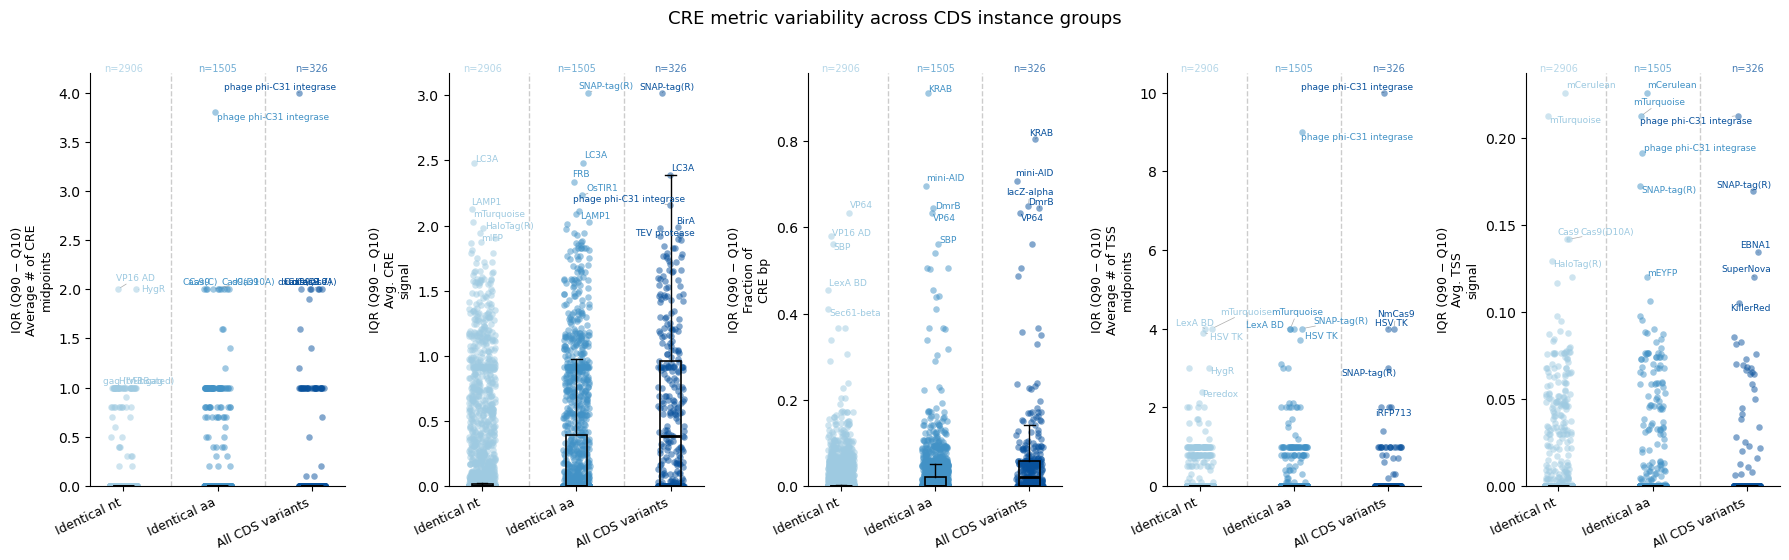

In [13]:
def compute_variability(
    values: np.ndarray,
    method: str = "range",
    q: float = 0.25,
) -> float:
    if len(values) < 2:
        return 0.0
    if method == "range":
        return float(np.max(values) - np.min(values))
    elif method == "iqr":
        return float(np.quantile(values, 1 - q) - np.quantile(values, q))
    else:
        raise ValueError(f"Unknown method {method!r}. Use 'range' or 'iqr'.")


def plot_cre_variability(
    df: pl.DataFrame,
    n_label: int = 5,
    method: str = "range",
    q: float = 0.25,
) -> plt.Figure:
    rng = np.random.default_rng(42)

    CENTERS = [0, 2, 4]
    JITTER  = 0.28
    BOX_W   = 0.45
    COLORS  = ["#9ecae1", "#4292c6", "#08519c"]   # ColorBrewer Blues: light → dark
    SECTION_LABELS = [
        "Identical nt",       # same nucleotide sequence
        "Identical aa",       # same amino acid sequence
        "All CDS variants",   # all instances of the same named CDS
    ]

    fig, axes = plt.subplots(1, 5, figsize=(18, 5.5))

    for ax, (col, ylabel) in zip(axes, METRICS):

        dfc = df.with_columns(pl.col(col).fill_nan(0.0).alias(col))

        def _range_df(group_cols: list[str], filter_expr=None) -> pl.DataFrame:
            agg = (
                dfc
                .group_by(group_cols)
                .agg([
                    pl.col(col).alias("values"),
                    pl.len().alias("n_instances"),
                    pl.col("unique_aa_id").n_unique().alias("n_aa_ids"),
                ])
                .with_columns(
                    pl.col("values").map_elements(
                        lambda v: compute_variability(
                            np.array(v), method=method, q=q
                        ),
                        return_dtype=pl.Float64,
                    ).alias("range")
                )
            )
            if filter_expr is not None:
                agg = agg.filter(filter_expr)
            return agg

        sections = [
            _range_df(
                ["feature_name", "unique_nuc_id"],
                pl.col("n_instances") >= 2,
            ),
            _range_df(
                ["feature_name", "unique_aa_id"],
                pl.col("n_instances") >= 2,
            ),
            _range_df(
                ["feature_name"],
                pl.col("n_aa_ids") >= 2,
            ),
        ]

        all_texts = []

        for sec_df, center, color in zip(sections, CENTERS, COLORS):
            if sec_df.is_empty():
                continue

            ranges = sec_df["range"].to_numpy()
            names  = sec_df["feature_name"].to_numpy()
            n      = len(ranges)

            xs = np.full(n, float(center)) + rng.uniform(-JITTER, JITTER, n)
            ax.scatter(
                xs, ranges,
                s=22, color=color, alpha=0.50,
                linewidths=0, zorder=2,
            )

            ax.boxplot(
                ranges,
                positions    = [center],
                widths       = BOX_W,
                patch_artist = True,
                showfliers   = False,
                zorder       = 3,
                medianprops  = {"color": "black", "lw": 2.0},
                boxprops     = {"facecolor": "none",
                                "edgecolor": "black", "linewidth": 1.2},
                whiskerprops = {"color": "black", "lw": 1.0},
                capprops     = {"color": "black", "lw": 1.0},
            )

            seen_names: set[str] = set()
            labeled = 0
            for i in np.argsort(ranges)[::-1]:
                if labeled >= n_label:
                    break
                nm = names[i]
                if nm in seen_names:
                    continue
                seen_names.add(nm)
                all_texts.append(
                    ax.text(xs[i], ranges[i], nm,
                            fontsize=6.5, color=color, zorder=5)
                )
                labeled += 1

        if all_texts:
            adjust_text(
                all_texts, ax=ax,
                arrowprops={"arrowstyle": "-", "color": "#aaaaaa", "lw": 0.5},
            )

        for div_x in [1.0, 3.0]:
            ax.axvline(div_x, color="#cccccc", lw=1.0, linestyle="--", zorder=1)

        y_top = ax.get_ylim()[1]
        for sec_df, center, color in zip(sections, CENTERS, COLORS):
            ax.text(center, y_top, f"n={sec_df.height}",
                    ha="center", va="bottom", fontsize=7,
                    color=color, alpha=0.75)

        ax.set_xticks(CENTERS)
        ax.set_xticklabels(SECTION_LABELS, fontsize=9,
                           rotation=25, ha="right")          # ← avoids overlap
        ax.set_xlim(-0.7, 4.7)

        var_label = (
            "Range (max − min)"
            if method == "range"
            else f"IQR (Q{int((1-q)*100)} − Q{int(q*100)})"
        )
        ax.set_ylabel(f"{var_label}\n{ylabel}", fontsize=9)
        ax.set_ylim(bottom=0)
        sns.despine(ax=ax)

    fig.suptitle(
        "CRE metric variability across CDS instance groups",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    return fig


# # Min-Max range
# fig1 = plot_cre_variability(cre_variability, method="range")

# # IQR (Q90 - Q10)
fig2 = plot_cre_variability(cre_variability, method="iqr", q=0.10)


Specific examples

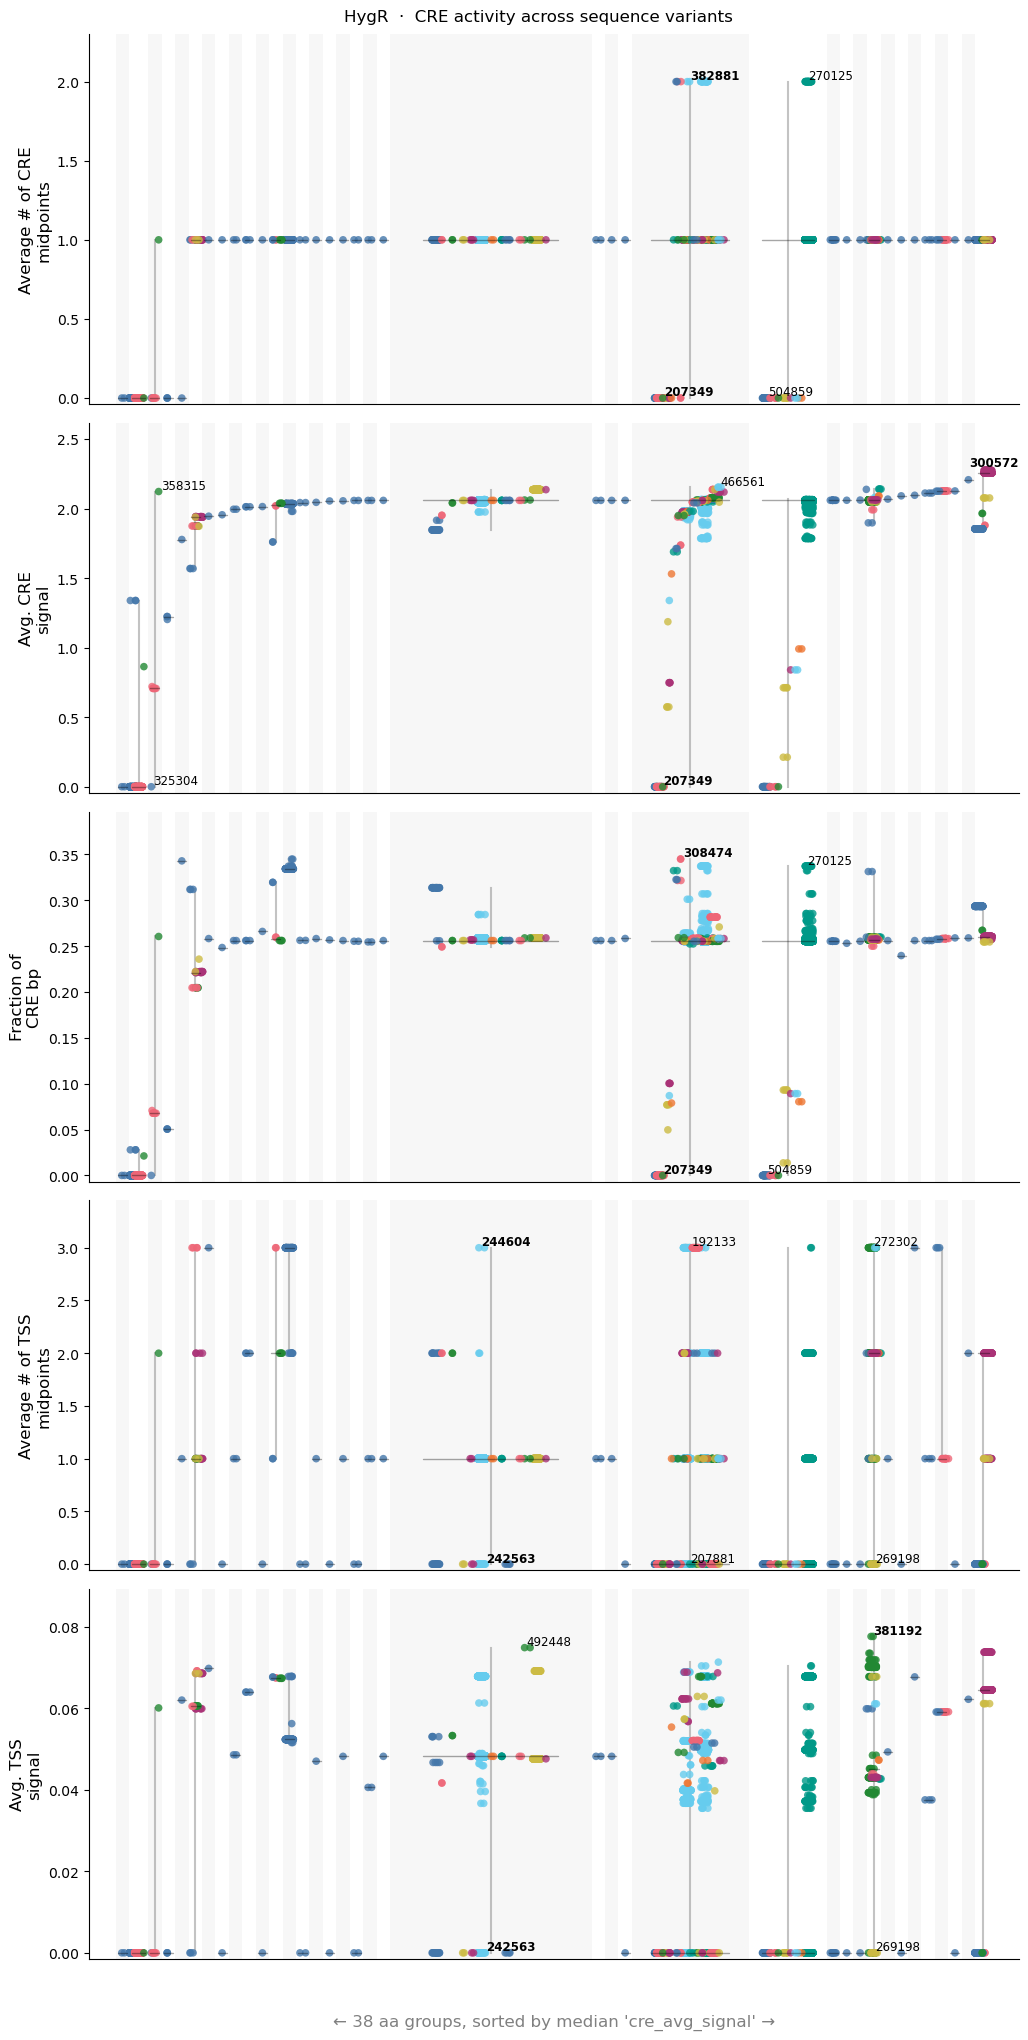

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from adjustText import adjust_text


def plot_cre_variability_instance(
    df: pl.DataFrame,
    feature_name: str,
    n_label: int = 2,
    sort_metric: str = "cre_avg_signal",
) -> plt.Figure:
    """
    Hierarchical strip plot of CRE metrics for a single named CDS (stacked vertically).

    X-axis : amino acid variant groups sorted by group median of `sort_metric` (left = low).
             Shared across all vertical subplots. Each group occupies one band;
             bands alternate grey/white with width proportional to instance count.
    Colour : nt variant within the aa group (cycling 8-colour palette, resets per aa group).
    Lines  :
      – thin grey vertical bar      = min–max range of the aa group
      – faint black horizontal tick = aa-group median
    """
    rng = np.random.default_rng(42)

    sub = df.filter(pl.col("feature_name") == feature_name)
    if sub.is_empty():
        raise ValueError(f"No instances found for feature_name={feature_name!r}")

    NT_PALETTE = [
        "#4477AA", "#EE6677", "#228833", "#CCBB44",
        "#AA3377", "#66CCEE", "#EE7733", "#009988",
    ]
    DOT_S = 30
    ALPHA = 0.8

    # Fall back to first available metric if specified sort_metric is missing
    if sort_metric not in sub.columns:
        sort_metric = METRICS[0][0]

    aas  = sub["unique_aa_id"].to_list()
    nucs = sub["unique_nuc_id"].to_list()
    gbks = [nm.removeprefix("sequence-").removesuffix("-") for nm in sub["gbk_name"].to_list()]
    n    = len(sub)

    # ── 1. Sort AA groups by median of sort_metric ───────────────────────────
    vals_sort = sub.with_columns(pl.col(sort_metric).fill_nan(0.0))[sort_metric].to_numpy()
    aa_all    = sub["unique_aa_id"].unique().to_list()
    aa_sorted = sorted(
        aa_all,
        key=lambda aid: float(
            np.median(vals_sort[[i for i, a in enumerate(aas) if a == aid]])
        ),
    )
    n_aa = len(aa_sorted)

    # ── 2. Calculate band widths & continuous x-positions ────────────────────
    aa_counts = {aid: sum(1 for a in aas if a == aid) for aid in aa_sorted}
    max_c = max(aa_counts.values())

    widths = {aid: max(0.1, 1.5 * (aa_counts[aid] / max_c)) for aid in aa_sorted}

    x_lefts, x_rights, aa_xpos = {}, {}, {}
    curr_x = 0.0
    for aid in aa_sorted:
        w = widths[aid]
        x_lefts[aid]  = curr_x
        x_rights[aid] = curr_x + w
        aa_xpos[aid]  = curr_x + w / 2.0
        curr_x += w

    # ── 3. Pre-calculate fixed X-positions for all instances ─────────────────
    all_xs   = np.zeros(n)
    all_cols = np.empty(n, dtype=object)

    for aid in aa_sorted:
        xctr   = aa_xpos[aid]
        w_band = widths[aid]
        half_w = w_band * 0.38
        a_idx  = [i for i, a in enumerate(aas) if a == aid]

        nt_seen: list = []
        for i in a_idx:
            if nucs[i] not in nt_seen:
                nt_seen.append(nucs[i])
        nt_med = {
            nid: float(np.median(vals_sort[[i for i in a_idx if nucs[i] == nid]]))
            for nid in nt_seen
        }
        nt_ord = sorted(nt_seen, key=lambda n: nt_med[n])
        n_nt   = len(nt_ord)
        nt_col = {nid: NT_PALETTE[j % len(NT_PALETTE)]
                  for j, nid in enumerate(nt_ord)}

        if n_nt == 1:
            nt_off = {nt_ord[0]: 0.0}
        else:
            span   = np.linspace(-half_w * 0.72, half_w * 0.72, n_nt)
            nt_off = dict(zip(nt_ord, span))

        for nid in nt_ord:
            nt_idx = [i for i in a_idx if nucs[i] == nid]
            m      = len(nt_idx)
            nt_x   = xctr + nt_off[nid]
            jitter = rng.uniform(-0.030, 0.030, m) if m > 1 else [0.0]

            for ki, i in enumerate(nt_idx):
                all_xs[i]   = nt_x + jitter[ki]
                all_cols[i] = nt_col[nid]

    # ── 4. Vertical subplots with shared X-axis ──────────────────────────────
    n_metrics = len(METRICS)
    fig, axes = plt.subplots(
        n_metrics, 1, figsize=(12, 5 * n_metrics), sharex=True,
        gridspec_kw={"hspace": 0.05}
    )

    for idx, (ax, (col, ylabel)) in enumerate(zip(axes, METRICS)):

        dfc  = sub.with_columns(pl.col(col).fill_nan(0.0).alias(col))
        vals = dfc[col].to_numpy()

        # Alternating background bands
        for k, aid in enumerate(aa_sorted):
            if k % 2 == 0:
                ax.axvspan(x_lefts[aid], x_rights[aid],
                           alpha=0.06, color="gray", zorder=0, lw=0)

        # Per-aa-group: range bars & median ticks for current metric
        for aid in aa_sorted:
            xctr   = aa_xpos[aid]
            w_band = widths[aid]
            half_w = w_band * 0.38
            a_idx  = [i for i, a in enumerate(aas) if a == aid]
            v_aa   = vals[a_idx]

            # faint aa-group median tick
            med = float(np.median(v_aa))
            ax.plot(
                [xctr - half_w * 0.88, xctr + half_w * 0.88],
                [med, med],
                color="black", lw=1.0, alpha=0.35, zorder=4,
                solid_capstyle="round",
            )

            # within-aa range bar
            if len(a_idx) > 1:
                ax.plot([xctr, xctr],
                        [float(v_aa.min()), float(v_aa.max())],
                        color="#888888", lw=1.5, alpha=0.50, zorder=2)

        # Scatter (dots sit on top of bars)
        ax.scatter(all_xs, vals,
                   c=list(all_cols), s=DOT_S, alpha=ALPHA,
                   linewidths=0, zorder=3)

        # Labels for extreme / variable points
        y_max   = float(np.max(vals)) if np.max(vals) > 0 else 1.0
        texts   = []
        labeled = set()

        # global extremes — bold
        for gi in [int(np.argmin(vals)), int(np.argmax(vals))]:
            if gi not in labeled:
                labeled.add(gi)
                texts.append(ax.text(all_xs[gi], vals[gi], gbks[gi],
                                     fontsize=8.5, color="black",
                                     fontweight="bold", zorder=6))

        # top-n variable aa groups
        aa_rng = {
            aid: float(
                np.max(vals[[i for i, a in enumerate(aas) if a == aid]])
                - np.min(vals[[i for i, a in enumerate(aas) if a == aid]])
            )
            for aid in aa_all
        }
        for aid in sorted(aa_all, key=lambda a: aa_rng[a], reverse=True)[:n_label]:
            a_idx = [i for i, a in enumerate(aas) if a == aid]
            for ci in [a_idx[int(np.argmin(vals[a_idx]))],
                       a_idx[int(np.argmax(vals[a_idx]))]]:
                if ci not in labeled:
                    labeled.add(ci)
                    texts.append(ax.text(all_xs[ci], vals[ci], gbks[ci],
                                         fontsize=8.5, color="black", zorder=5))

        if texts:
            adjust_text(texts, ax=ax, arrowprops={"arrowstyle": "-", "color": "#cccccc", "lw": 0.5})

        # Axes chrome
        ax.set_xlim(-0.2, curr_x + 0.2)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(-0.02 * y_max, y_max * 1.15)
        sns.despine(ax=ax)

        # X-axis annotations on the bottom panel only
        if idx == n_metrics - 1:
            ax.set_xticks([])
            ax.text(0.5, -0.18,
                    f"← {n_aa} aa groups, sorted by median '{sort_metric}' →",
                    transform=ax.transAxes, ha="center", fontsize=12, color="gray")

    fig.suptitle(f"{feature_name}  ·  CRE activity across sequence variants", y=0.89)
    return fig


fig_inst = plot_cre_variability_instance(cre_variability, feature_name="HygR")
plt.show()


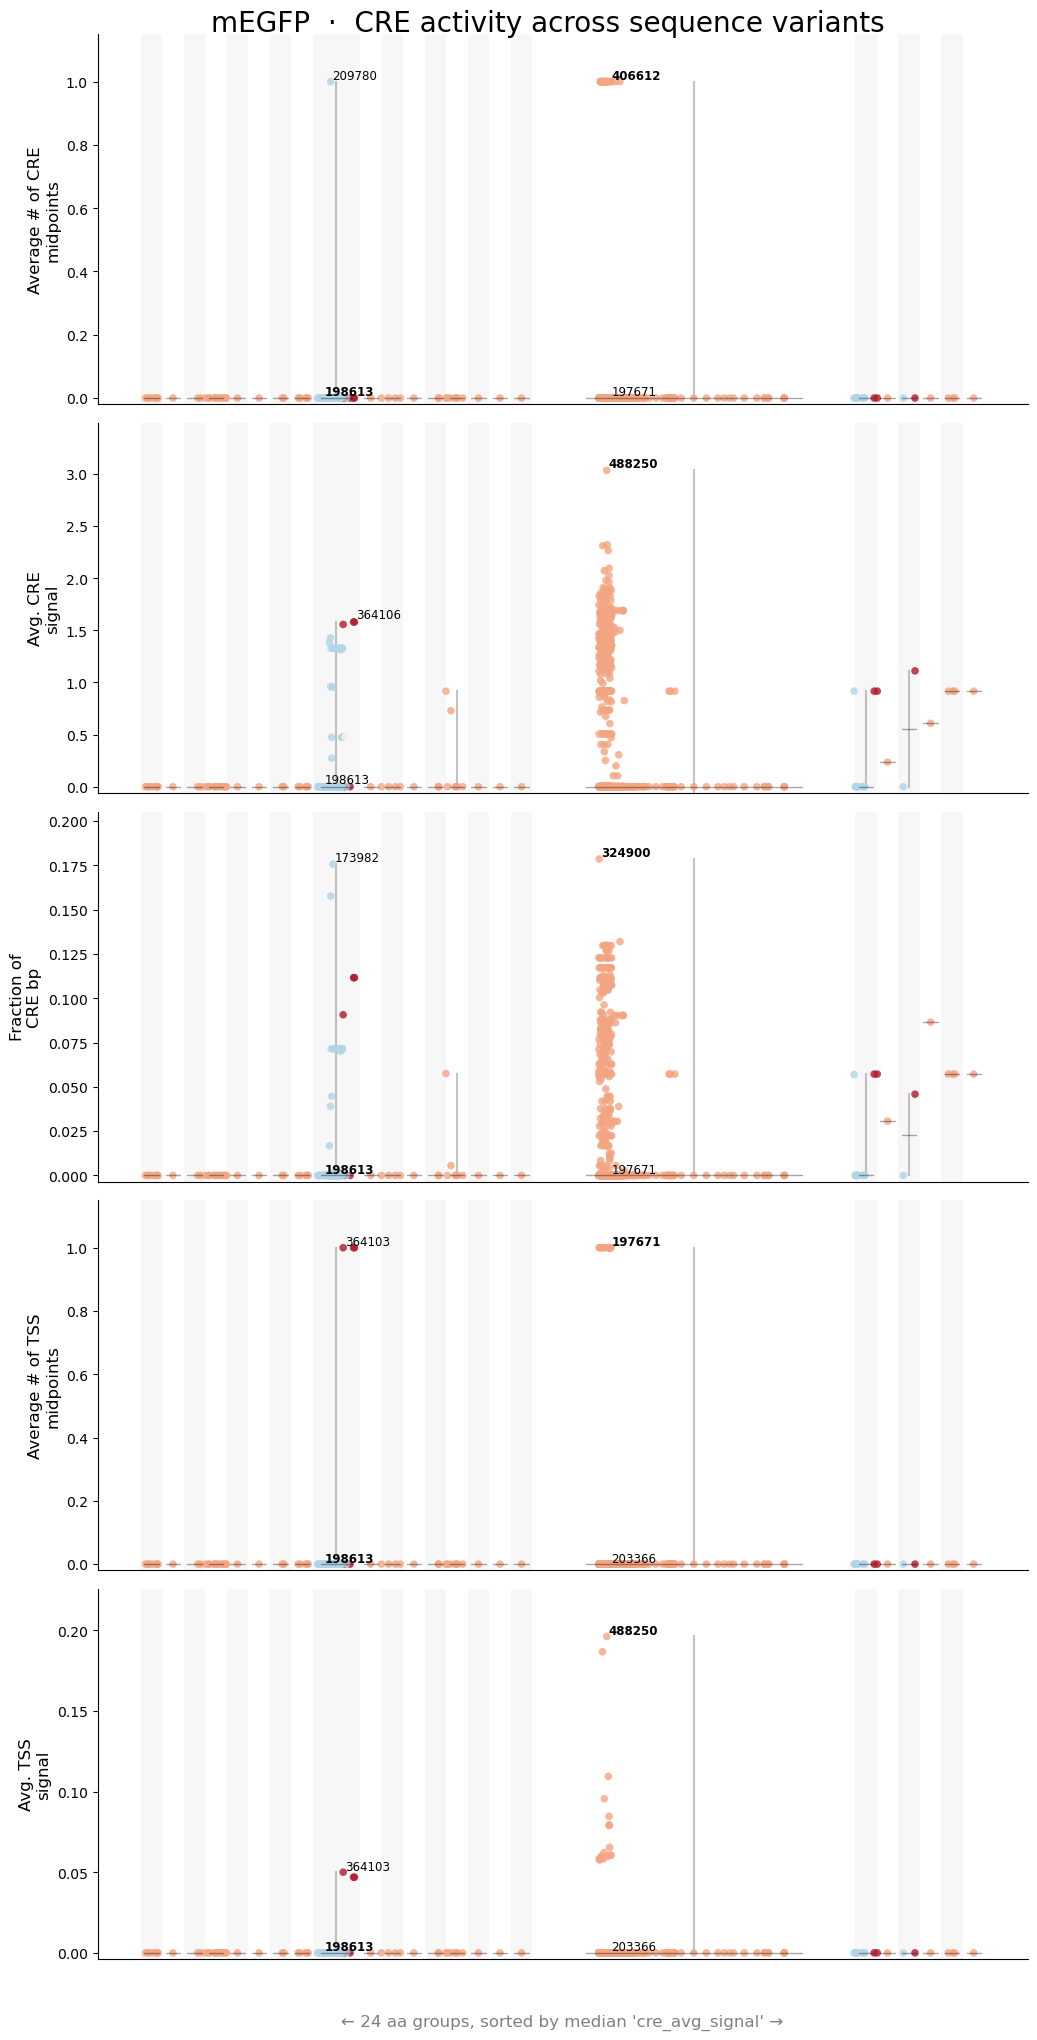

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from adjustText import adjust_text


def plot_cre_variability_instance(
    df: pl.DataFrame,
    feature_name: str,
    n_label: int = 2,
    sort_metric: str = "cre_avg_signal",
) -> plt.Figure:
    """
    Hierarchical strip plot of CRE metrics for a single named CDS (stacked vertically).

    X-axis : amino acid variant groups sorted by group median of `sort_metric` (left = low).
             Shared across all vertical subplots. Each group occupies one band;
             bands alternate grey/white with width proportional to instance count.
    Colour : nt variant within the aa group scaled from light blue (lowest relative median
             activity in the aa group) to dark blue (highest relative median activity).
    Lines  :
      – thin grey vertical bar      = min–max range of the aa group
      – faint black horizontal tick = aa-group median
    """
    rng = np.random.default_rng(42)

    sub = df.filter(pl.col("feature_name") == feature_name)
    if sub.is_empty():
        raise ValueError(f"No instances found for feature_name={feature_name!r}")

    CMAP = plt.cm.RdBu_r
    DOT_S = 30
    ALPHA = 0.8

    # Fall back to first available metric if specified sort_metric is missing
    if sort_metric not in sub.columns:
        sort_metric = METRICS[0][0]

    aas  = sub["unique_aa_id"].to_list()
    nucs = sub["unique_nuc_id"].to_list()
    gbks = [nm.removeprefix("sequence-").removesuffix("-") for nm in sub["gbk_name"].to_list()]
    n    = len(sub)

    # ── 1. Sort AA groups by median of sort_metric ───────────────────────────
    vals_sort = sub.with_columns(pl.col(sort_metric).fill_nan(0.0))[sort_metric].to_numpy()
    aa_all    = sub["unique_aa_id"].unique().to_list()
    aa_sorted = sorted(
        aa_all,
        key=lambda aid: float(
            np.median(vals_sort[[i for i, a in enumerate(aas) if a == aid]])
        ),
    )
    n_aa = len(aa_sorted)

    # ── 2. Calculate band widths & continuous x-positions ────────────────────
    aa_counts = {aid: sum(1 for a in aas if a == aid) for aid in aa_sorted}
    max_c = max(aa_counts.values())

    widths = {aid: max(0.1, 1.5 * (aa_counts[aid] / max_c)) for aid in aa_sorted}

    x_lefts, x_rights, aa_xpos = {}, {}, {}
    curr_x = 0.0
    for aid in aa_sorted:
        w = widths[aid]
        x_lefts[aid]  = curr_x
        x_rights[aid] = curr_x + w
        aa_xpos[aid]  = curr_x + w / 2.0
        curr_x += w

    # ── 3. Pre-calculate fixed X-positions and gradient colors ───────────────
    all_xs   = np.zeros(n)
    all_cols = np.empty(n, dtype=object)

    for aid in aa_sorted:
        xctr   = aa_xpos[aid]
        w_band = widths[aid]
        half_w = w_band * 0.38
        a_idx  = [i for i, a in enumerate(aas) if a == aid]

        nt_seen: list = []
        for i in a_idx:
            if nucs[i] not in nt_seen:
                nt_seen.append(nucs[i])
        nt_med = {
            nid: float(np.median(vals_sort[[i for i in a_idx if nucs[i] == nid]]))
            for nid in nt_seen
        }
        nt_ord = sorted(nt_seen, key=lambda n: nt_med[n])
        n_nt   = len(nt_ord)

        # Map relative medians to a blue gradient (0.35 = light blue, 0.90 = dark blue for background contrast)
        min_m = min(nt_med.values())
        max_m = max(nt_med.values())

        if n_nt == 1 or max_m == min_m:
            nt_col = {nid: CMAP(0.70) for nid in nt_seen}
        else:
            nt_col = {
                nid: CMAP(0.35 + 0.55 * (nt_med[nid] - min_m) / (max_m - min_m))
                for nid in nt_seen
            }

        if n_nt == 1:
            nt_off = {nt_ord[0]: 0.0}
        else:
            span   = np.linspace(-half_w * 0.72, half_w * 0.72, n_nt)
            nt_off = dict(zip(nt_ord, span))

        for nid in nt_ord:
            nt_idx = [i for i in a_idx if nucs[i] == nid]
            m      = len(nt_idx)
            nt_x   = xctr + nt_off[nid]
            jitter = rng.uniform(-0.030, 0.030, m) if m > 1 else [0.0]

            for ki, i in enumerate(nt_idx):
                all_xs[i]   = nt_x + jitter[ki]
                all_cols[i] = nt_col[nid]

    # ── 4. Vertical subplots with shared X-axis ──────────────────────────────
    n_metrics = len(METRICS)
    fig, axes = plt.subplots(
        n_metrics, 1, figsize=(12, 5 * n_metrics), sharex=True,
        gridspec_kw={"hspace": 0.05}
    )

    for idx, (ax, (col, ylabel)) in enumerate(zip(axes, METRICS)):

        dfc  = sub.with_columns(pl.col(col).fill_nan(0.0).alias(col))
        vals = dfc[col].to_numpy()

        # Alternating background bands
        for k, aid in enumerate(aa_sorted):
            if k % 2 == 0:
                ax.axvspan(x_lefts[aid], x_rights[aid],
                           alpha=0.06, color="gray", zorder=0, lw=0)

        # Per-aa-group: range bars & median ticks for current metric
        for aid in aa_sorted:
            xctr   = aa_xpos[aid]
            w_band = widths[aid]
            half_w = w_band * 0.38
            a_idx  = [i for i, a in enumerate(aas) if a == aid]
            v_aa   = vals[a_idx]

            # faint aa-group median tick
            med = float(np.median(v_aa))
            ax.plot(
                [xctr - half_w * 0.88, xctr + half_w * 0.88],
                [med, med],
                color="black", lw=1.0, alpha=0.35, zorder=4,
                solid_capstyle="round",
            )

            # within-aa range bar
            if len(a_idx) > 1:
                ax.plot([xctr, xctr],
                        [float(v_aa.min()), float(v_aa.max())],
                        color="#888888", lw=1.5, alpha=0.50, zorder=2)

        # Scatter (dots sit on top of bars)
        ax.scatter(all_xs, vals,
                   c=list(all_cols), s=DOT_S, alpha=ALPHA,
                   linewidths=0, zorder=3)

        # Labels for extreme / variable points
        y_max   = float(np.max(vals)) if np.max(vals) > 0 else 1.0
        texts   = []
        labeled = set()

        # global extremes — bold
        for gi in [int(np.argmin(vals)), int(np.argmax(vals))]:
            if gi not in labeled:
                labeled.add(gi)
                texts.append(ax.text(all_xs[gi], vals[gi], gbks[gi],
                                     fontsize=8.5, color="black",
                                     fontweight="bold", zorder=6))

        # top-n variable aa groups
        aa_rng = {
            aid: float(
                np.max(vals[[i for i, a in enumerate(aas) if a == aid]])
                - np.min(vals[[i for i, a in enumerate(aas) if a == aid]])
            )
            for aid in aa_all
        }
        for aid in sorted(aa_all, key=lambda a: aa_rng[a], reverse=True)[:n_label]:
            a_idx = [i for i, a in enumerate(aas) if a == aid]
            for ci in [a_idx[int(np.argmin(vals[a_idx]))],
                       a_idx[int(np.argmax(vals[a_idx]))]]:
                if ci not in labeled:
                    labeled.add(ci)
                    texts.append(ax.text(all_xs[ci], vals[ci], gbks[ci],
                                         fontsize=8.5, color="black", zorder=5))

        if texts:
            adjust_text(texts, ax=ax, arrowprops={"arrowstyle": "-", "color": "#cccccc", "lw": 0.5})

        # Axes chrome
        ax.set_xlim(-0.2, curr_x + 0.2)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(-0.02 * y_max, y_max * 1.15)
        sns.despine(ax=ax)

        # X-axis annotations on the bottom panel only
        if idx == n_metrics - 1:
            ax.set_xticks([])
            ax.text(0.5, -0.18,
                    f"← {n_aa} aa groups, sorted by median '{sort_metric}' →",
                    transform=ax.transAxes, ha="center", fontsize=12, color="gray")

    fig.suptitle(f"{feature_name}  ·  CRE activity across sequence variants", fontsize=20, y=0.89)
    return fig


fig_inst = plot_cre_variability_instance(cre_variability, feature_name="mEGFP")
plt.show()


In [ ]:
(
    cre_variability
    .filter(pl.col("feature_name") == "phage phi-C31 integrase")
    # ["unique_nuc_id"].unique()
)

feature_type,feature_name,unique_nuc_id,unique_aa_id,gbk_name,position,strand,length,n_cre_midpoints,n_tss_midpoints,n_tss_fwd_midpoints,n_tss_rev_midpoints,cre_avg_signal,tss_fwd_avg_signal,tss_rev_avg_signal,tss_avg_signal,fraction_cre_bp
str,str,str,str,str,list[list[i64]],i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""CDS""","""phage phi-C31 integrase""","""CDS__phage_phi-C31_integrase||…","""CDS__phage_phi-C31_integrase||…","""sequence-250824-""","[[1616, 3434]]",1,1818,2,0,0,0,1.805967,NaN,NaN,NaN,0.190319
"""CDS""","""phage phi-C31 integrase""","""CDS__phage_phi-C31_integrase||…","""CDS__phage_phi-C31_integrase||…","""sequence-498728-""","[[2773, 4588]]",1,1815,0,0,0,0,0.530359,NaN,NaN,NaN,0.000551
"""CDS""","""phage phi-C31 integrase""","""CDS__phage_phi-C31_integrase||…","""CDS__phage_phi-C31_integrase||…","""sequence-491429-""","[[311, 2126]]",1,1815,0,0,0,0,NaN,NaN,0.062329,0.062329,0.0
"""CDS""","""phage phi-C31 integrase""","""CDS__phage_phi-C31_integrase||…","""CDS__phage_phi-C31_integrase||…","""sequence-491425-""","[[2018, 3833]]",1,1815,0,0,0,0,NaN,NaN,0.052184,0.052184,0.0
"""CDS""","""phage phi-C31 integrase""","""CDS__phage_phi-C31_integrase||…","""CDS__phage_phi-C31_integrase||…","""sequence-363931-""","[[1802, 3617]]",1,1815,0,0,0,0,NaN,NaN,NaN,NaN,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CDS""","""phage phi-C31 integrase""","""CDS__phage_phi-C31_integrase||…","""CDS__phage_phi-C31_integrase||…","""sequence-409587-""","[[1754, 3569]]",1,1815,1,0,0,0,1.67193,NaN,NaN,NaN,0.063361
"""CDS""","""phage phi-C31 integrase""","""CDS__phage_phi-C31_integrase||…","""CDS__phage_phi-C31_integrase||…","""sequence-409571-""","[[3904, 5719]]",1,1815,1,0,0,0,1.67193,NaN,NaN,NaN,0.063361
"""CDS""","""phage phi-C31 integrase""","""CDS__phage_phi-C31_integrase||…","""CDS__phage_phi-C31_integrase||…","""sequence-409577-""","[[1693, 3508]]",1,1815,1,0,0,0,1.67193,NaN,NaN,NaN,0.063361


**Codon optimization cases**

In [ ]:
cds_modifications = pl.read_csv(MANUAL_DIR / "addgene_cds_modifications.csv")

cds_modifications["modification_type"].value_counts().sort("count", descending=True)

modification_type,count
str,u32
"""sequence_version_update""",21
"""tandem_repeat_expansion""",15
"""monomerization""",7
"""single_lysine_chain_specific_v…",7
"""spectral_engineering""",7
…,…
"""point_mutation""",1
"""activation_domain_fusion""",1
"""photostability_engineering""",1
